# Art Style Transfer Model

## Step 1: Import libraries and model

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Image functions

In [18]:
def load_image(image_path, max_dim=512):
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((max_dim, max_dim)),
        transforms.ToTensor(),
    ])
    image = transform(image).unsqueeze(0)  # Add batch dimension
    return image

In [19]:
def deprocess_image(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image.permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)
    return image

In [20]:
class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()
        vgg = models.vgg19(pretrained=True).features.eval()
        self.content_layers = ['conv_4']
        self.style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']
        self.layers = []
        self.model = nn.Sequential()
        i = 0
        for layer in vgg.children():
            if isinstance(layer, nn.Conv2d):
                i += 1
                name = f'conv_{i}'
            elif isinstance(layer, nn.ReLU):
                name = f'relu_{i}'
                layer = nn.ReLU(inplace=False)
            elif isinstance(layer, nn.MaxPool2d):
                name = f'pool_{i}'
            elif isinstance(layer, nn.BatchNorm2d):
                name = f'bn_{i}'
            self.model.add_module(name, layer)
            if name in self.content_layers + self.style_layers:
                self.layers.append(name)
            if len(self.layers) == len(self.content_layers) + len(self.style_layers):
                break

    def forward(self, x):
        features = {}
        for name, layer in self.model.named_children():
            x = layer(x)
            if name in self.layers:
                features[name] = x
        return features


In [21]:
def gram_matrix(tensor):
    _, c, h, w = tensor.size()
    tensor = tensor.view(c, h * w)
    return torch.mm(tensor, tensor.t()) / (c * h * w)

In [22]:
def compute_loss(model, target_image, content_image, style_image, content_weight, style_weight):
    target_features = model(target_image)
    content_features = model(content_image)
    style_features = model(style_image)

    content_loss = torch.mean((target_features['conv_4'] - content_features['conv_4']) ** 2)
    style_loss = 0
    for layer in model.style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_gram = gram_matrix(style_features[layer])
        style_loss += torch.mean((target_gram - style_gram) ** 2)
    style_loss /= len(model.style_layers)
    return content_weight * content_loss + style_weight * style_loss

In [ ]:
def style_transfer(content_path, style_path, num_iterations=1000, content_weight=1e3, style_weight=1e-1, lr=0.003):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VGG().to(device).eval()
    content_image = load_image(content_path).to(device)
    style_image = load_image(style_path).to(device)
    target_image = content_image.clone().requires_grad_(True)
    optimizer = optim.Adam([target_image], lr=lr)
    for i in range(num_iterations):
        optimizer.zero_grad()
        loss = compute_loss(model, target_image, content_image, style_image, content_weight, style_weight)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            target_image.clamp_(0, 1)
        if i % 10 == 0:
            print(f'Iteration {i}, Loss: {loss.item():.4f}')
    return deprocess_image(target_image)

## Step 3: Run training

Iteration 0, Loss: 0.0000
Iteration 10, Loss: 2.2472
Iteration 20, Loss: 0.6868
Iteration 30, Loss: 0.2740
Iteration 40, Loss: 0.1214
Iteration 50, Loss: 0.0604
Iteration 60, Loss: 0.0347
Iteration 70, Loss: 0.0231
Iteration 80, Loss: 0.0176
Iteration 90, Loss: 0.0146
Iteration 100, Loss: 0.0128
Iteration 110, Loss: 0.0116
Iteration 120, Loss: 0.0107
Iteration 130, Loss: 0.0100
Iteration 140, Loss: 0.0095
Iteration 150, Loss: 0.0090
Iteration 160, Loss: 0.0087
Iteration 170, Loss: 0.0084
Iteration 180, Loss: 0.0082
Iteration 190, Loss: 0.0080
Iteration 200, Loss: 0.0078
Iteration 210, Loss: 0.0076
Iteration 220, Loss: 0.0075
Iteration 230, Loss: 0.0074
Iteration 240, Loss: 0.0073
Iteration 250, Loss: 0.0073
Iteration 260, Loss: 0.0072
Iteration 270, Loss: 0.0072
Iteration 280, Loss: 0.0073
Iteration 290, Loss: 0.0073
Iteration 300, Loss: 0.0073
Iteration 310, Loss: 0.0074
Iteration 320, Loss: 0.0076
Iteration 330, Loss: 0.0080
Iteration 340, Loss: 0.0082
Iteration 350, Loss: 0.0084
Ite

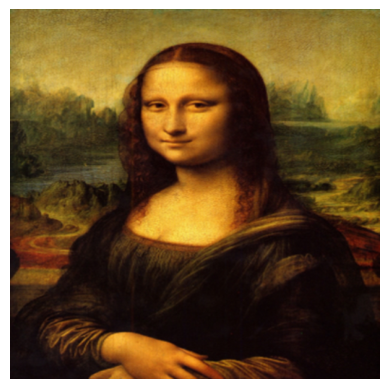

In [24]:
# Run style transfer
var_iterations = 1000

content_path = './images/rect/original.png'
style_path = './images/rect/style.png'
stylized_image = style_transfer(content_path, style_path, num_iterations=var_iterations)
plt.imshow(stylized_image)
plt.axis('off')
plt.show()
Image.fromarray((stylized_image * 255).astype('uint8')).save(f'./images/export/PyTorch/stylized_image-{var_iterations}_iterations.png')